Mounted at /content/drive
데이터 형태: (3341, 8) (3341, 3) (836, 8) (836, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 867 (3.39 KB)

 Trainable params: 867 (3.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
209/209 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5307 - loss: 0.8857 - val_accuracy: 0.5359 - val_loss: 0.8746
Epoch 2/50
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5435 - loss: 0.8582 - val_accuracy: 0.5490 - val_loss: 0.8622
Epoch 3/50
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5468 - loss: 0.8528 - val_accuracy: 0.5634 - val_loss: 0.8535
Epoch 4/50
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5543 - loss: 0.8462 - val_accuracy: 0.5598 - val_loss: 0.8474
Epoch 5/50
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5645 - loss: 0.8416 - val_accuracy: 0.5550 - val_loss: 0.8429
Epoch 6/50
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5669 - loss: 0.8375 - val_accuracy: 0.5730 - val_loss: 0.8384
Epoch 7/50
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5645 - loss: 0.8375 - val_accuracy: 0.5789 - val_loss: 0.8378
Epoch 8/50
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5771 - loss: 0.8326 - val_accuracy: 0.

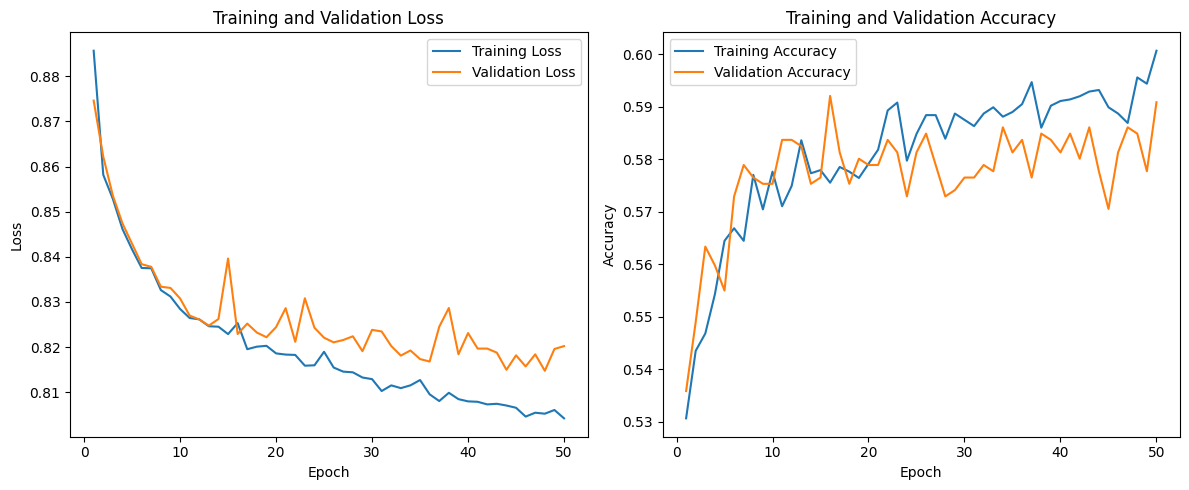


=== 최종 모델 평가 (evaluate) ===
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5909 - loss: 0.8202

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.49      0.44      0.46       249
           1       0.72      0.82      0.77       291
           2       0.52      0.50      0.51       296

    accuracy                           0.59       836
   macro avg       0.58      0.58      0.58       836
weighted avg       0.58      0.59      0.58       836


=== Confusion Matrix ===
[[109  36 104]
 [ 19 238  34]
 [ 93  56 147]]


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from keras.models import Sequential
from keras.layers import Dense
from google.colab import drive

drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/abalone.csv")

df = df.drop('id', axis=1)

X_data = df.drop('Sex', axis=1)
y_data = df['Sex']

scaler = StandardScaler()
X = scaler.fit_transform(X_data)

Y = pd.get_dummies(y_data).values

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

print("데이터 형태:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

model = Sequential()
model.add(Dense(32, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dense(16, activation='relu'))

model.add(Dense(Y.shape[1], activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

N_EPOCHS = 50
history = model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=16, validation_data=(X_test, y_test), verbose=1)

y_pred = model.predict(X_test)
y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, N_EPOCHS + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, N_EPOCHS + 1), history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, N_EPOCHS + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, N_EPOCHS + 1), history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

print("\n=== 최종 모델 평가 (evaluate) ===")
model.evaluate(X_test, y_test)

print("\n=== Classification Report ===")
print(classification_report(y_test_class, y_pred_class))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test_class, y_pred_class))